# Geraçõ de gráficos

## Utilizando o Pandas

In [1]:
import pandas as pd

In [2]:
# As chaves do dicionário são os nomes das colunas, as listas são valores
dados = {
    "nome": ["Ana", "Bruno", "Carlos", "Daniela", "Eduardo", "Gustavo", "Gabriel", "Marcos"],
    "idade": [22, 25, 21, 28, 24, 23, 22, 20],
    "curso": [
        "Python",
        "Python",
        "Machine Learning",
        "Python",
        "Machine Learning",
        "Machine Learning",
        "Python",
        "Machine Learning"
    ],
    "nota": [8.5, 7.0, 9.2, 6.5, 8.0, 9.0, 7.4, 8.8]
}

data_frame = pd.DataFrame(dados)

data_frame

,nome,idade,curso,nota
0,Ana,22,Python,8.5
1,Bruno,25,Python,7.0
2,Carlos,21,Machine Learning,9.2
3,Daniela,28,Python,6.5
4,Eduardo,24,Machine Learning,8.0
5,Gustavo,23,Machine Learning,9.0
6,Gabriel,22,Python,7.4
7,Marcos,20,Machine Learning,8.8


In [3]:
# DataFrame com uma coluna de índice para facilitar o plot de gráficos
data_plot = data_frame.reset_index()

## Plotando histograma

<Axes: >

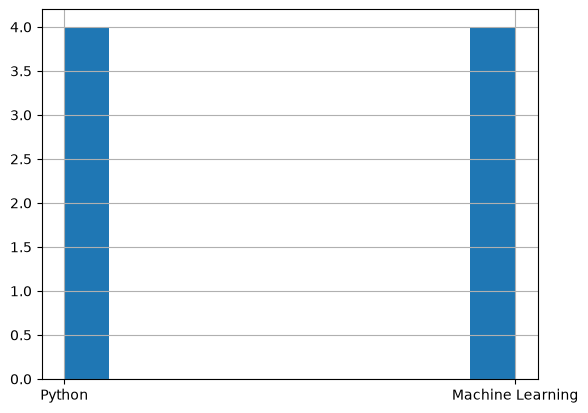

In [4]:
# Forma direta
data_plot["curso"].hist()

<Axes: xlabel='curso'>

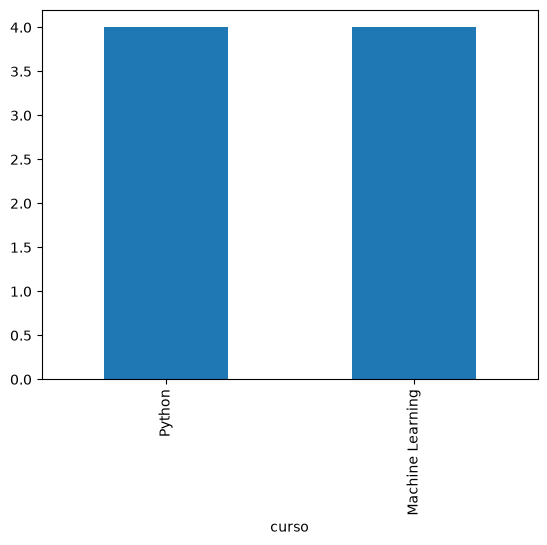

In [5]:
# Forma com plot customizado
data_plot["curso"].value_counts().plot(kind="bar")

## Plotando gráfico de dispersão

<Axes: xlabel='index', ylabel='idade'>

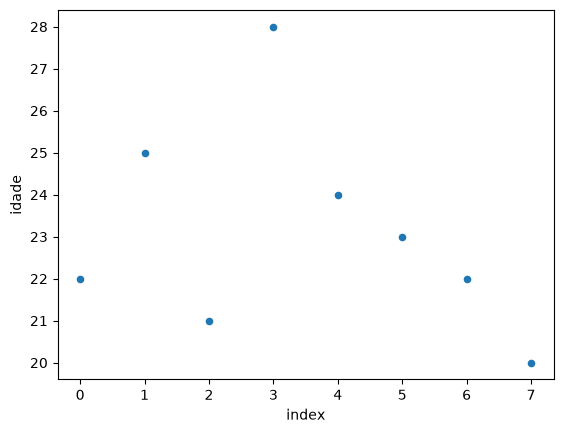

In [6]:
data_plot.plot.scatter(x="index", y="idade")

## Plotando boxplot

<Axes: >

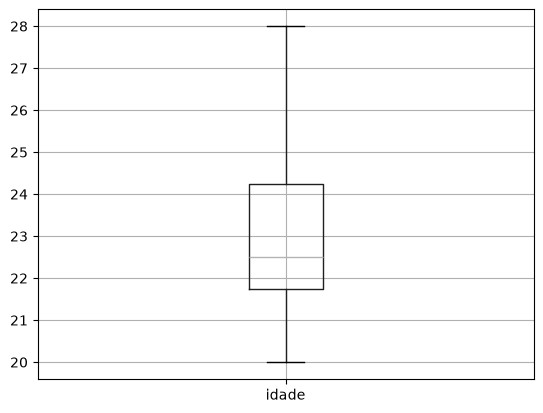

In [7]:
data_plot.boxplot(column="idade")

<Axes: title={'center': 'idade'}, xlabel='curso'>

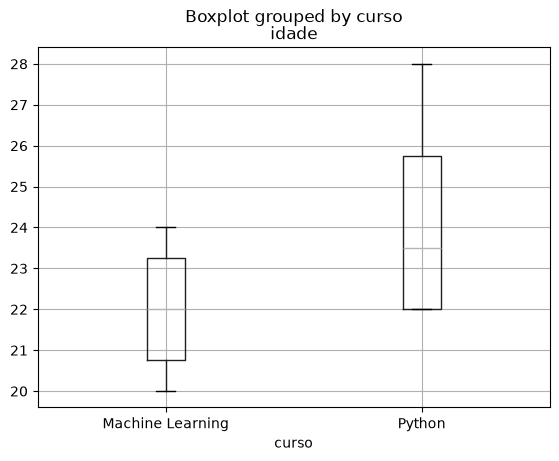

In [8]:
# Boxplot com agrupamento
data_plot.boxplot(by="curso", column="idade")

<Axes: title={'center': 'nota'}, xlabel='curso'>

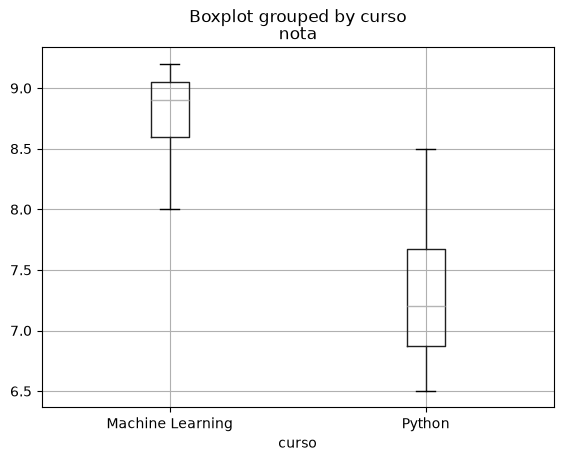

In [9]:
data_plot.boxplot(by="curso", column="nota")

## Gráfico personalizado com Matplotlib

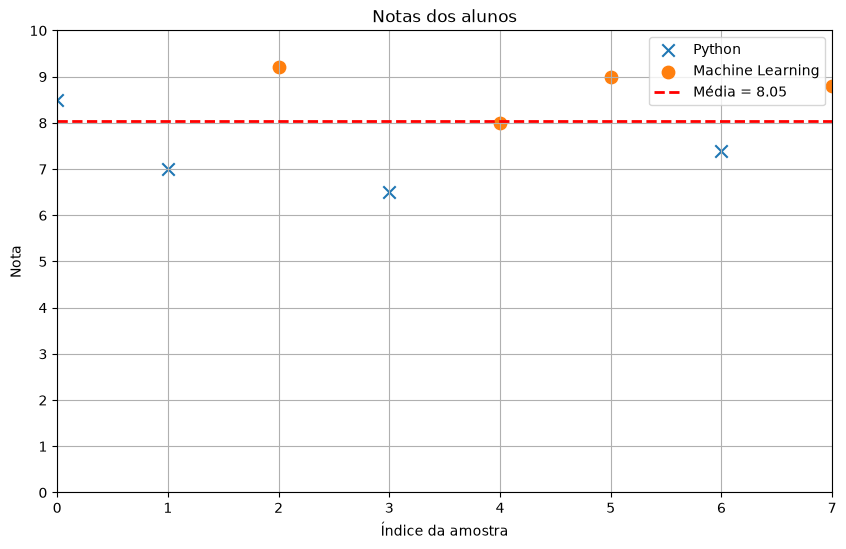

In [10]:
import matplotlib.pyplot as plt

# Média de todas as notas
media = data_plot["nota"].mean()

# Configuração do gráfico
plt.figure(figsize=(10, 6))

# Filtrando valores
notas_python = data_plot.loc[data_plot["curso"] == "Python", ["index", "nota"]]
notas_ml = data_plot.loc[data_plot["curso"] == "Machine Learning", ["index", "nota"]]

# Plotando conjuntos dados de dispersão
plt.scatter(
    notas_python["index"],  # eixo X = índice
    notas_python["nota"],   # eixo Y = nota
    label="Python",         # Legenda
    marker="x",             # Marcador
    s=80,                   # Tamanho do marcador
)

plt.scatter(
    notas_ml["index"],
    notas_ml["nota"],
    label="Machine Learning",
    marker="o",
    s=80
)

# Utilizando agrupamento para plotar
# for curso, grupo in data_plot.groupby("curso"):
#     plt.scatter(
#         grupo.index,
#         grupo["nota"],
#         label=curso,
#         s=80
#     )

# Linha da média
plt.axhline(
    y=media,
    linestyle="--",
    linewidth=2,
    label=f"Média = {media:.2f}",
    color="red"
)

# Título
plt.title("Notas dos alunos")

# Nome dos eixos
plt.xlabel("Índice da amostra")
plt.ylabel("Nota")

# Limites dos eixos
plt.xlim(0, 7)
plt.ylim(0, 10)

# Definir intervalo das linhas de escala
plt.xticks(range(0, 8, 1))
plt.yticks(range(0, 11, 1))

# Colocar grade
plt.grid(True)

# Gerar legenda
plt.legend()

# Exibir gráfico
plt.show()